# AGNN
Following the original implementation of Phung et al., The training scripts (01 to 04) train the models and evaluate them. Each writes its predictions and metric tables to `results/tables/`. This notebook loads those result CSVs and creates the AGNN figures.

Figures written to `results/figures/`:



In [ ]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

## 1. Load helpers and labels

In [ ]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# read the evaluation results
OUT_TABLES = os.path.join("results", "tables")
OUT_FIGURES = os.path.join("results", "figures")
os.makedirs(OUT_FIGURES, exist_ok=True)


def have(name):
    return os.path.exists(os.path.join(OUT_TABLES, name))


def load(name):
    return pd.read_csv(os.path.join(OUT_TABLES, name))


# labels and ordering for the SQ2 ablation figure, matching the training script
ABL_ORDER = ["no_lcs", "no_era5", "no_eac4", "no_era5_eac4", "no_era5_eac4_lcs",
             "no_network", "no_time", "raw"]
ABL_LABEL = {
    "no_lcs": "LCS",
    "no_era5": "ERA5",
    "no_eac4": "EAC4",
    "no_era5_eac4": "ERA5+EAC4",
    "no_era5_eac4_lcs": "ERA5+EAC4+LCS",
    "no_network": "Neighbours",
    "no_time": "Time",
    "raw": "Engineered features",
}
SEASON_ORDER = ["Winter", "Spring", "Summer", "Autumn"]

print("tables dir:", OUT_TABLES)
print("figures dir:", OUT_FIGURES)


tables dir: results\tables
figures dir: results\figures


## SQ1: overall accuracy and the best week figure

Reads `sq1_summary.csv`, `sq1_per_station_metrics.csv` and `sq1_predictions.csv`. The best week figure is the station-week of 2024 with the
lowest AGNN RMSE.


31 stations:
         aggregation  RMSE  MAE   R2
  mean over stations  2.85 2.12 0.74
median over stations  2.68 1.94 0.79

best AGNN week: NL01487_PM2.5_lucht | week of 2024-04-15 | RMSE 0.62


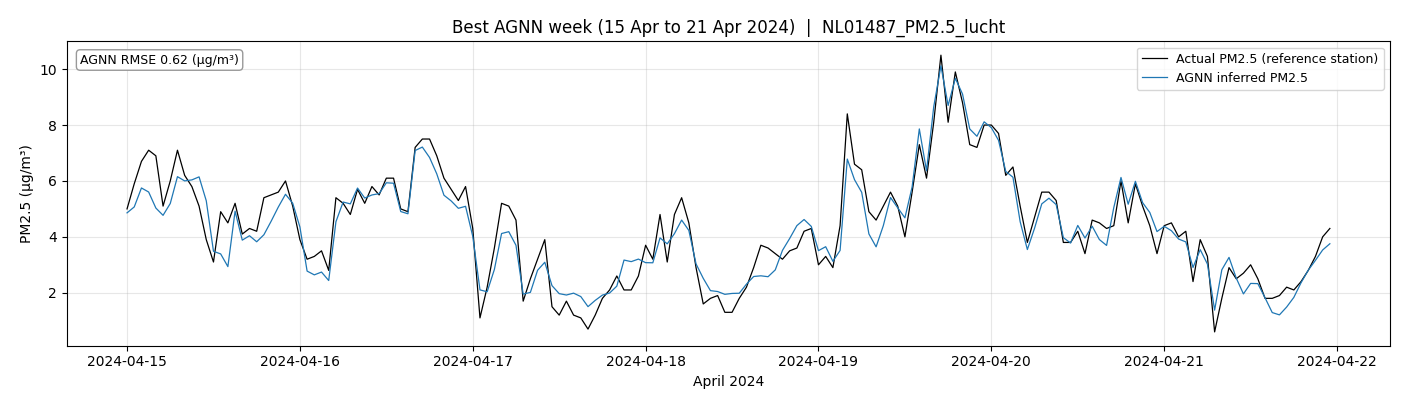

saved: results\figures\sq1_best_week.png


In [ ]:
if have("sq1_summary.csv") and have("sq1_predictions.csv"):
    summary = load("sq1_summary.csv")
    per_station = load("sq1_per_station_metrics.csv")
    predictions = load("sq1_predictions.csv")
    predictions["datetime"] = pd.to_datetime(predictions["datetime"])

    print("%d stations:" % len(per_station))
    print(summary.round(2).to_string(index=False))

    def rmse_of(group):
        err = (group["y_pred"] - group["y_true"]).values
        err = err[~np.isnan(err)]
        return float(np.sqrt(np.mean(err ** 2))) if len(err) else np.nan

    pw = predictions.copy()
    pw["week_start"] = (pw["datetime"] - pd.to_timedelta(pw["datetime"].dt.dayofweek, unit="D")).dt.normalize()
    rows = []
    for (station, week_start), group in pw.groupby(["station_id", "week_start"]):
        if len(group) < 160:
            continue  # incomplete week at the edge of the year
        rows.append({"station_id": station, "week_start": week_start, "RMSE": rmse_of(group)})
    weekly = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
    best = weekly.iloc[0]
    print()
    print("best AGNN week:", best["station_id"], "| week of", best["week_start"].date(),
          "| RMSE", round(best["RMSE"], 3))

    station = best["station_id"]
    start = best["week_start"]
    end = start + pd.Timedelta(days=7)
    week = predictions[(predictions["station_id"] == station)
                       & (predictions["datetime"] >= start)
                       & (predictions["datetime"] < end)].sort_values("datetime")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(week["datetime"], week["y_true"], color="black", linewidth=0.9,
            label="Actual PM2.5 (reference station)")
    ax.plot(week["datetime"], week["y_pred"], color="tab:blue", linewidth=0.9,
            label="AGNN inferred PM2.5")
    ax.set_ylabel("PM2.5 (µg/m³)")
    ax.set_xlabel(start.strftime("%B %Y"))
    title = "Best AGNN week (" + start.strftime("%d %b") + " to " + (end - pd.Timedelta(days=1)).strftime("%d %b %Y") + ")  |  " + station
    ax.set_title(title)
    ax.text(0.01, 0.96, "AGNN RMSE %.2f (µg/m³)" % best["RMSE"], transform=ax.transAxes,
            va="top", ha="left", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.6"))
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_FIGURES, "sq1_best_week.png"), dpi=200, bbox_inches="tight")
    plt.show()
    print("saved:", os.path.join(OUT_FIGURES, "sq1_best_week.png"))



## SQ2: feature ablation bars

Reads `sq2_summary.csv` (mean RMSE and R2 per variant) and `sq2_wilcoxon_vs_full.csv` 


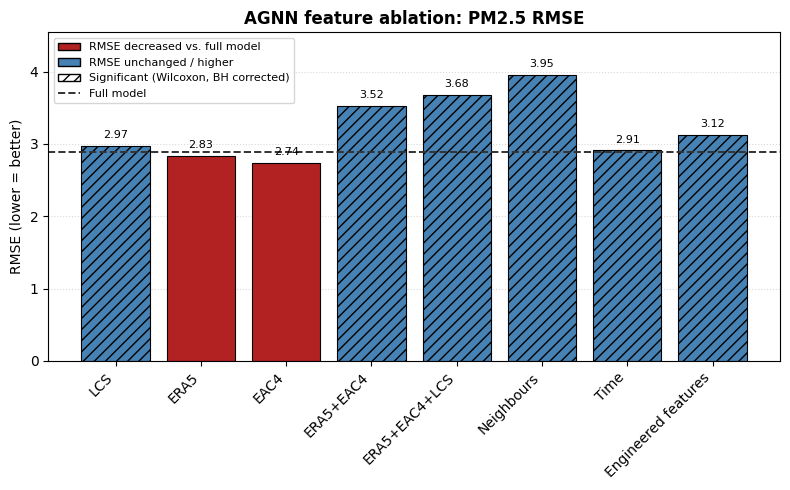

saved: results\figures\sq2_ablation_rmse_bars.png


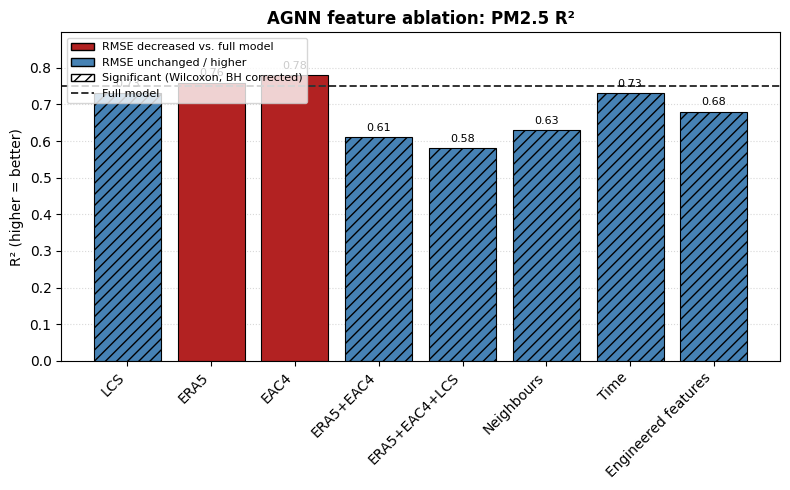

saved: results\figures\sq2_ablation_r2_bars.png


In [ ]:
if have("sq2_summary.csv") and have("sq2_wilcoxon_vs_full.csv"):
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D

    summ = load("sq2_summary.csv")
    wil = load("sq2_wilcoxon_vs_full.csv")

    RED = "firebrick"
    BLUE = "steelblue"
    full_rmse = float(summ.loc[summ["ablation"] == "full", "mean_RMSE"].iloc[0])
    full_r2 = float(summ.loc[summ["ablation"] == "full", "mean_R2"].iloc[0])

    labels = []
    rmse_values = []
    r2_values = []
    colors = []
    sig_flags = []
    for name in ABL_ORDER:
        hit = summ[summ["ablation"] == name]
        if len(hit) == 0:
            continue
        labels.append(ABL_LABEL[name])
        v_rmse = float(hit["mean_RMSE"].iloc[0])
        v_r2 = float(hit["mean_R2"].iloc[0])
        rmse_values.append(v_rmse)
        r2_values.append(v_r2)
        colors.append(RED if v_rmse < full_rmse else BLUE)
        wrow = wil[wil["ablation"] == name]
        sig_flags.append(bool(wrow["significant"].iloc[0]) if len(wrow) else False)

    legend_items = [
        Patch(facecolor=RED, edgecolor="black", label="RMSE decreased vs. full model"),
        Patch(facecolor=BLUE, edgecolor="black", label="RMSE unchanged / higher"),
        Patch(facecolor="white", edgecolor="black", hatch="///", label="Significant (Wilcoxon, BH corrected)"),
        Line2D([0], [0], color="0.2", linestyle="--", linewidth=1.4, label="Full model"),
    ]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(labels, rmse_values, color=colors, edgecolor="black", linewidth=0.8)
    for i in range(len(bars)):
        if sig_flags[i]:
            bars[i].set_hatch("///")
        ax.text(bars[i].get_x() + bars[i].get_width() / 2.0, rmse_values[i] + 0.08,
                "%.2f" % rmse_values[i], ha="center", va="bottom", fontsize=8)
    ax.axhline(full_rmse, color="0.2", linestyle="--", linewidth=1.4)
    ax.set_ylabel("RMSE (lower = better)")
    ax.set_ylim(0, max(rmse_values) * 1.15)
    ax.set_title("AGNN feature ablation: PM2.5 RMSE", fontweight="bold")
    ax.tick_params(axis="x", labelrotation=45)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")
    ax.grid(axis="y", color="0.85", linestyle=":")
    ax.set_axisbelow(True)
    ax.legend(handles=legend_items, loc="upper left", fontsize=8, frameon=True)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_FIGURES, "sq2_ablation_rmse_bars.png"), dpi=200, bbox_inches="tight")
    plt.show()
    print("saved:", os.path.join(OUT_FIGURES, "sq2_ablation_rmse_bars.png"))

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(labels, r2_values, color=colors, edgecolor="black", linewidth=0.8)
    for i in range(len(bars)):
        if sig_flags[i]:
            bars[i].set_hatch("///")
        ax.text(bars[i].get_x() + bars[i].get_width() / 2.0, r2_values[i] + 0.012,
                "%.2f" % r2_values[i], ha="center", va="bottom", fontsize=8)
    ax.axhline(full_r2, color="0.2", linestyle="--", linewidth=1.4)
    ax.set_ylabel("R² (higher = better)")
    ax.set_ylim(0, max(r2_values) * 1.15)
    ax.set_title("AGNN feature ablation: PM2.5 R²", fontweight="bold")
    ax.tick_params(axis="x", labelrotation=45)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")
    ax.grid(axis="y", color="0.85", linestyle=":")
    ax.set_axisbelow(True)
    ax.legend(handles=legend_items, loc="upper left", fontsize=8, frameon=True)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_FIGURES, "sq2_ablation_r2_bars.png"), dpi=200, bbox_inches="tight")
    plt.show()
    print("saved:", os.path.join(OUT_FIGURES, "sq2_ablation_r2_bars.png"))
else:
    print("sq2 result CSVs not found, run 02_sq2_feature_ablations.py first")


## SQ3: distance band degradation

Reads `sq3_summary.csv` (mean and median RMSE and R2 per exclusion radius). 


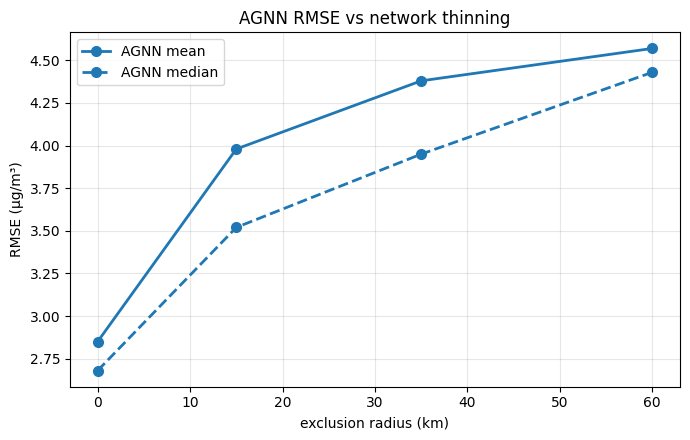

saved: results\figures\sq3_rmse_vs_radius.png


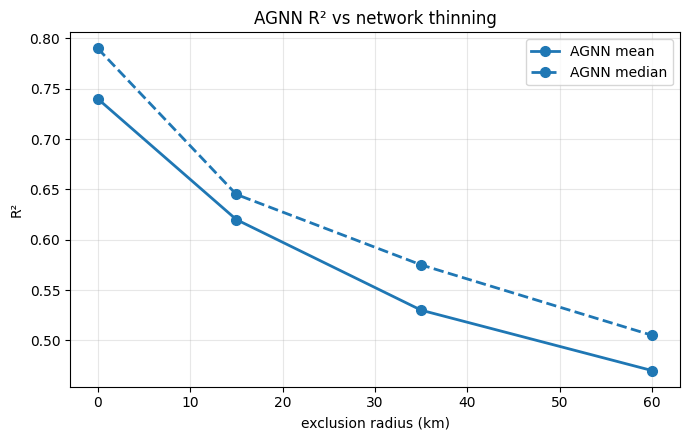

saved: results\figures\sq3_r2_vs_radius.png


In [ ]:
if have("sq3_summary.csv"):
    summ = load("sq3_summary.csv").sort_values("radius_km")
    
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(summ["radius_km"], summ["mean_RMSE"], marker="o", markersize=7,
            color="tab:blue", linewidth=2, label="AGNN mean")
    ax.plot(summ["radius_km"], summ["median_RMSE"], marker="o", markersize=7,
            color="tab:blue", linewidth=2, linestyle="--", label="AGNN median")
    ax.set_xlabel("exclusion radius (km)")
    ax.set_ylabel("RMSE (µg/m³)")
    ax.set_title("AGNN RMSE vs network thinning")
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_FIGURES, "sq3_rmse_vs_radius.png"), dpi=200, bbox_inches="tight")
    plt.show()
    print("saved:", os.path.join(OUT_FIGURES, "sq3_rmse_vs_radius.png"))

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(summ["radius_km"], summ["mean_R2"], marker="o", markersize=7,
            color="tab:blue", linewidth=2, label="AGNN mean")
    ax.plot(summ["radius_km"], summ["median_R2"], marker="o", markersize=7,
            color="tab:blue", linewidth=2, linestyle="--", label="AGNN median")
    ax.set_xlabel("exclusion radius (km)")
    ax.set_ylabel("R²")
    ax.set_title("AGNN R² vs network thinning")
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_FIGURES, "sq3_r2_vs_radius.png"), dpi=200, bbox_inches="tight")
    plt.show()
    print("saved:", os.path.join(OUT_FIGURES, "sq3_r2_vs_radius.png"))
else:
    print("sq3 result CSVs not found, run 03_sq3_distance_bands.py first")


## SQ4: seasonal bars

Reads `sq4_seasonal_table.csv` (mean concentration, RMSE, normalized RMSE, MAE
and R2 per meteorological season). Left bars are absolute RMSE, right bars are
RMSE normalized by the seasonal mean concentration.


season  mean_conc  RMSE  nRMSE  MAE   R2
Winter       9.51  3.24   0.34 2.27 0.63
Spring       9.12  2.77   0.30 2.08 0.84
Summer       7.11  2.41   0.34 2.01 0.80
Autumn       8.88  3.07   0.35 2.12 0.69



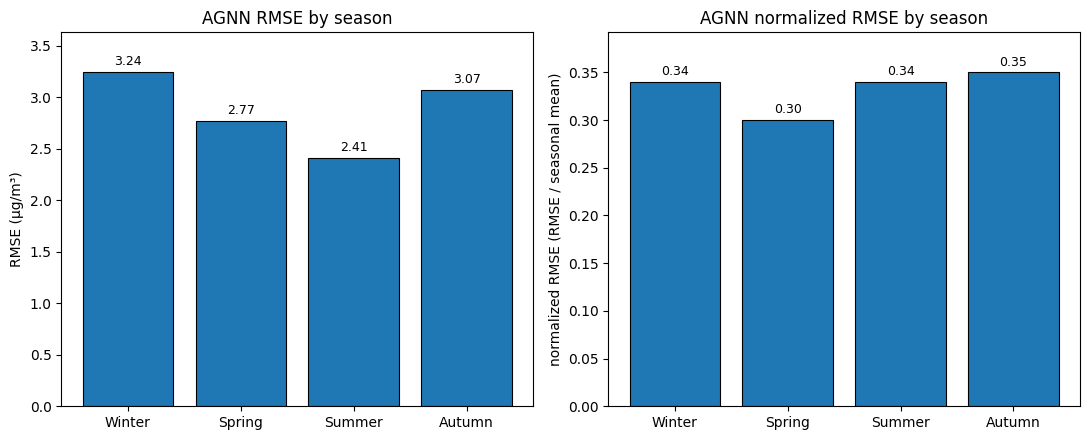

saved: results\figures\sq4_seasonal_bars.png


In [ ]:
if have("sq4_seasonal_table.csv"):
    season_table = load("sq4_seasonal_table.csv")
    # keep the meteorological order even if the CSV is in another order
    season_table = season_table.set_index("season").reindex(SEASON_ORDER).reset_index()
    print(season_table.round(2).to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].bar(season_table["season"], season_table["RMSE"], color="tab:blue",
                edgecolor="black", linewidth=0.8)
    for i in range(len(season_table)):
        axes[0].text(i, season_table["RMSE"].iloc[i] + 0.05, "%.2f" % season_table["RMSE"].iloc[i],
                     ha="center", va="bottom", fontsize=9)
    axes[0].set_ylabel("RMSE (µg/m³)")
    axes[0].set_title("AGNN RMSE by season")
    axes[0].grid(axis="y", alpha=0.3)
    axes[0].set_axisbelow(True)

    axes[1].bar(season_table["season"], season_table["nRMSE"], color="tab:blue",
                edgecolor="black", linewidth=0.8)
    for i in range(len(season_table)):
        axes[1].text(i, season_table["nRMSE"].iloc[i] + 0.005, "%.2f" % season_table["nRMSE"].iloc[i],
                     ha="center", va="bottom", fontsize=9)
    axes[1].set_ylabel("normalized RMSE (RMSE / seasonal mean)")
    axes[1].set_title("AGNN normalized RMSE by season")
    axes[1].grid(axis="y", alpha=0.3)
    axes[1].set_axisbelow(True)

    fig.tight_layout()
    fig.savefig(os.path.join(OUT_FIGURES, "sq4_seasonal_bars.png"), dpi=200, bbox_inches="tight")
    plt.show()
    print("saved:", os.path.join(OUT_FIGURES, "sq4_seasonal_bars.png"))
else:
    print("sq4 result CSVs not found, run 04_sq4_seasonal_performance.py first")
